# Adaptive PD/NonPD fusion PoC

This experiment tests whether two heterogeneous neural experts—one temporal and one spectral—can be adaptively combined using the uncertainty of their calibrated probabilities.

Only `Tr0` is used for training, `Va0` for early stopping/calibration/threshold selection, and `Te0` for final evaluation. Partitions `Te1` and `Te2` are not loaded. This is a PoC, not a final benchmark.

In [10]:
import hashlib
import json
import os
import random
import struct
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from researchdata import get_dataset


def locate_project_root():
    configured = os.environ.get('PD_POC_PROJECT_ROOT')
    candidates = []
    if configured:
        candidates.append(Path(configured).expanduser().resolve())
    current = Path.cwd().resolve()
    candidates.extend([current, current.parent, current.parent.parent, current.parent.parent.parent])
    for candidate in candidates:
        if (candidate / 'poc' / 'experiments' / 'poc.ipynb').is_file() and (candidate / 'data' / 'datasets.yaml').is_file():
            return candidate
    raise RuntimeError('Could not locate the workspace root; use PD_POC_PROJECT_ROOT.')


PROJECT_ROOT = locate_project_root()
DATASET_STORE = os.environ.get('RESEARCHHUB_DATASET_STORE')
if not DATASET_STORE:
    raise RuntimeError('Configure RESEARCHHUB_DATASET_STORE before running the PoC.')
SEED = int(os.environ.get('PD_POC_SEED', '42'))
DEVICE_NAME = os.environ.get('PD_POC_DEVICE', 'cpu').lower()
if DEVICE_NAME == 'cuda' and not torch.cuda.is_available():
    raise RuntimeError('PD_POC_DEVICE=cuda but CUDA is not available in this environment.')
DEVICE = torch.device(DEVICE_NAME)
MAX_EPOCHS = int(os.environ.get('PD_POC_MAX_EPOCHS', '20'))
PATIENCE = int(os.environ.get('PD_POC_PATIENCE', '5'))
BATCH_SIZE = int(os.environ.get('PD_POC_BATCH_SIZE', '128'))

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(int(os.environ.get('PD_POC_TORCH_THREADS', '2')))

EXPECTED_COUNTS = {
    'Tr0.mat': {0: 6130, 1: 6130},
    'Va0.mat': {0: 1533, 1: 1533},
    'Te0.mat': {0: 22985, 1: 22985},
}

dataset = get_dataset('dataset-pd-noise', version='v1')
if not dataset.available():
    raise RuntimeError('dataset-pd-noise@v1 is not available in the configured catalog.')
PARTITION_FILES = ('Tr0.mat', 'Va0.mat', 'Te0.mat')
PARTITION_PATHS = {file_id: dataset.path(file_id) for file_id in PARTITION_FILES}


def _decode_matlab_categorical(workspace, n_samples):
    # MATLAB v5 stores categorical codes here as a miUINT8 element.
    raw = np.asarray(workspace, dtype=np.uint8).reshape(-1).tobytes()
    pd_marker = bytes([16, 0, 2, 0]) + b'PD'
    if b'NonPD' not in raw or pd_marker not in raw:
        raise ValueError('The NonPD/PD categories were not found in the MATLAB payload.')
    marker = struct.pack('<II', 2, n_samples)
    candidates = []
    offset = 0
    while True:
        position = raw.find(marker, offset)
        if position < 0:
            break
        code_start = position + len(marker)
        codes = np.frombuffer(raw, dtype=np.uint8, count=n_samples, offset=code_start).copy()
        if codes.size == n_samples and np.all(np.isin(codes, [1, 2])):
            candidates.append(codes)
        offset = position + 1
    if len(candidates) != 1:
        raise ValueError(f'Could not uniquely identify categorical codes: {len(candidates)} candidates.')
    # The categoryNames order in these files is NonPD=1, PD=2.
    return (candidates[0] == 2).astype(np.int64)


def load_partition(file_id):
    if file_id not in PARTITION_FILES:
        raise ValueError(f'Partition is outside the PoC scope: {file_id}')
    path = PARTITION_PATHS[file_id]
    table = Path(file_id).stem
    mat = loadmat(path, squeeze_me=False, struct_as_record=False, variable_names=[table, '__function_workspace__'])
    record = mat[table][0, 0]
    signal_cells = np.asarray(record.signals, dtype=object).reshape(-1)
    signals = np.stack([np.asarray(item, dtype=np.float32).reshape(-1) for item in signal_cells])
    if signals.ndim != 2 or signals.shape[1] != 400:
        raise ValueError(f'{file_id}: unexpected signal shape: {signals.shape}')
    labels = _decode_matlab_categorical(mat['__function_workspace__'], signals.shape[0])
    counts = dict(sorted(Counter(labels.tolist()).items()))
    if counts != EXPECTED_COUNTS[file_id]:
        raise ValueError(f'{file_id}: counts {counts}; expected {EXPECTED_COUNTS[file_id]}')
    if not np.isfinite(signals).all():
        raise ValueError(f'{file_id}: signals contain non-finite values.')
    return signals, labels


partitions = {file_id: load_partition(file_id) for file_id in PARTITION_FILES}
loaded_partitions = tuple(partitions)
assert loaded_partitions == PARTITION_FILES
assert set(loaded_partitions).isdisjoint({'Te1.mat', 'Te2.mat'})
audit = pd.DataFrame(
    [
        {'partition': file_id, 'n_samples': int(x.shape[0]), 'n_features': int(x.shape[1]), 'NonPD': int((y == 0).sum()), 'PD': int((y == 1).sum())}
        for file_id, (x, y) in partitions.items()
    ]
)
display(audit)
print(f'Project: {PROJECT_ROOT.name}')
print(f'Dataset: {dataset.dataset_id}@{dataset.version}')
print(f'Device: {DEVICE}; seed: {SEED}; loaded partitions: {loaded_partitions}')


,partition,n_samples,n_features,NonPD,PD
0,Tr0.mat,12260,400,6130,6130
1,Va0.mat,3066,400,1533,1533
2,Te0.mat,45970,400,22985,22985


Project: PRJ-2026-003-partial-discharge-adaptive-fusion
Dataset: dataset-pd-noise@v1
Device: cpu; seed: 42; loaded partitions: ('Tr0.mat', 'Va0.mat', 'Te0.mat')


In [11]:
X_train, y_train = partitions['Tr0.mat']
X_val, y_val = partitions['Va0.mat']
X_test, y_test = partitions['Te0.mat']


def fit_standardizer(values):
    mean = values.mean(axis=0, keepdims=True).astype(np.float32)
    std = values.std(axis=0, keepdims=True).astype(np.float32)
    std[std < 1e-6] = 1.0
    return mean, std


def apply_standardizer(values, mean, std):
    return ((values - mean) / std).astype(np.float32)


def fft_magnitude(values):
    return np.log1p(np.abs(np.fft.rfft(values, axis=1))).astype(np.float32)


raw_mean, raw_std = fit_standardizer(X_train)
fft_train = fft_magnitude(X_train)
fft_mean, fft_std = fit_standardizer(fft_train)

raw_inputs = {
    'train': apply_standardizer(X_train, raw_mean, raw_std)[:, None, :],
    'val': apply_standardizer(X_val, raw_mean, raw_std)[:, None, :],
    'test': apply_standardizer(X_test, raw_mean, raw_std)[:, None, :],
}
fft_inputs = {
    'train': apply_standardizer(fft_train, fft_mean, fft_std)[:, None, :],
    'val': apply_standardizer(fft_magnitude(X_val), fft_mean, fft_std)[:, None, :],
    'test': apply_standardizer(fft_magnitude(X_test), fft_mean, fft_std)[:, None, :],
}


class TinyCNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(64, 1)

    def forward(self, inputs):
        features = self.features(inputs).squeeze(-1)
        return self.classifier(features).squeeze(-1)


def predict_logits(model, inputs):
    loader = DataLoader(TensorDataset(torch.from_numpy(inputs)), batch_size=512, shuffle=False)
    model.eval()
    batches = []
    with torch.no_grad():
        for (batch,) in loader:
            batches.append(model(batch.to(DEVICE)).detach().cpu().numpy())
    return np.concatenate(batches).astype(np.float64)


def train_expert(inputs):
    model = TinyCNN1D().to(DEVICE)
    train_dataset = TensorDataset(torch.from_numpy(inputs['train']), torch.from_numpy(y_train.astype(np.float32)))
    train_generator = torch.Generator()
    train_generator.manual_seed(SEED)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=train_generator)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_state = None
    best_mcc = -np.inf
    stale_epochs = 0
    history = []
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        losses = []
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        val_logits = predict_logits(model, inputs['val'])
        val_prob = sigmoid(val_logits)
        val_mcc = float(matthews_corrcoef(y_val, val_prob >= 0.5))
        history.append({'epoch': epoch, 'train_loss': float(np.mean(losses)), 'val_mcc_at_0.5': val_mcc})
        if val_mcc > best_mcc + 1e-12:
            best_mcc = val_mcc
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
        if stale_epochs >= PATIENCE:
            break
    if best_state is None:
        raise RuntimeError('Training did not produce a valid state.')
    model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, history


def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.clip(values, -40, 40)))


experts = {}
histories = {}
for expert_name, inputs in [('temporal', raw_inputs), ('spectral', fft_inputs)]:
    print(f'Training {expert_name} expert...')
    experts[expert_name], histories[expert_name] = train_expert(inputs)
    print(f'  epochs={len(histories[expert_name])}, best_val_mcc@0.5={max(item["val_mcc_at_0.5"] for item in histories[expert_name]):.4f}')


def fit_temperature(logits, labels):
    temperatures = np.exp(np.linspace(np.log(0.25), np.log(4.0), 81))
    labels = labels.astype(np.float64)
    scores = []
    for temperature in temperatures:
        scaled = logits / temperature
        scores.append(float(np.mean(np.logaddexp(0.0, scaled) - labels * scaled)))
    return float(temperatures[int(np.argmin(scores))])


logits = {
    expert_name: {
        'val': predict_logits(model, inputs['val']),
        'test': predict_logits(model, inputs['test']),
    }
    for expert_name, (model, inputs) in [('temporal', (experts['temporal'], raw_inputs)), ('spectral', (experts['spectral'], fft_inputs))]
}
temperatures = {expert_name: fit_temperature(values['val'], y_val) for expert_name, values in logits.items()}
probabilities = {
    expert_name: {split: sigmoid(values[split] / temperatures[expert_name]) for split in ('val', 'test')}
    for expert_name, values in logits.items()
}
print(f'Calibration temperatures: {temperatures}')


Training temporal expert...
  epochs=14, best_val_mcc@0.5=0.9288
Training spectral expert...
  epochs=12, best_val_mcc@0.5=0.8626
Calibration temperatures: {'temporal': 0.7071067811865475, 'spectral': 0.8408964152537145}


,threshold,mcc,f1,accuracy,roc_auc,pr_auc,recall_tpr,fpr,ece_10_bins
temporal,0.245,0.948920,0.973982,0.974309,0.995773,0.996424,0.961714,0.013095,0.022904
adaptive_entropy,0.230,0.944383,0.971603,0.972003,0.995228,0.996068,0.957886,0.013879,0.027843
fixed_mean,0.360,0.940015,0.969558,0.969893,0.995291,0.995950,0.958886,0.019099,0.038529
spectral,0.465,0.861092,0.927410,0.929693,0.980808,0.983593,0.898238,0.038851,0.024494


Best baseline MCC: 0.9489
Adaptive gain versus best baseline: -0.0045
PoC criterion met: False; automatic recommendation: REVISE


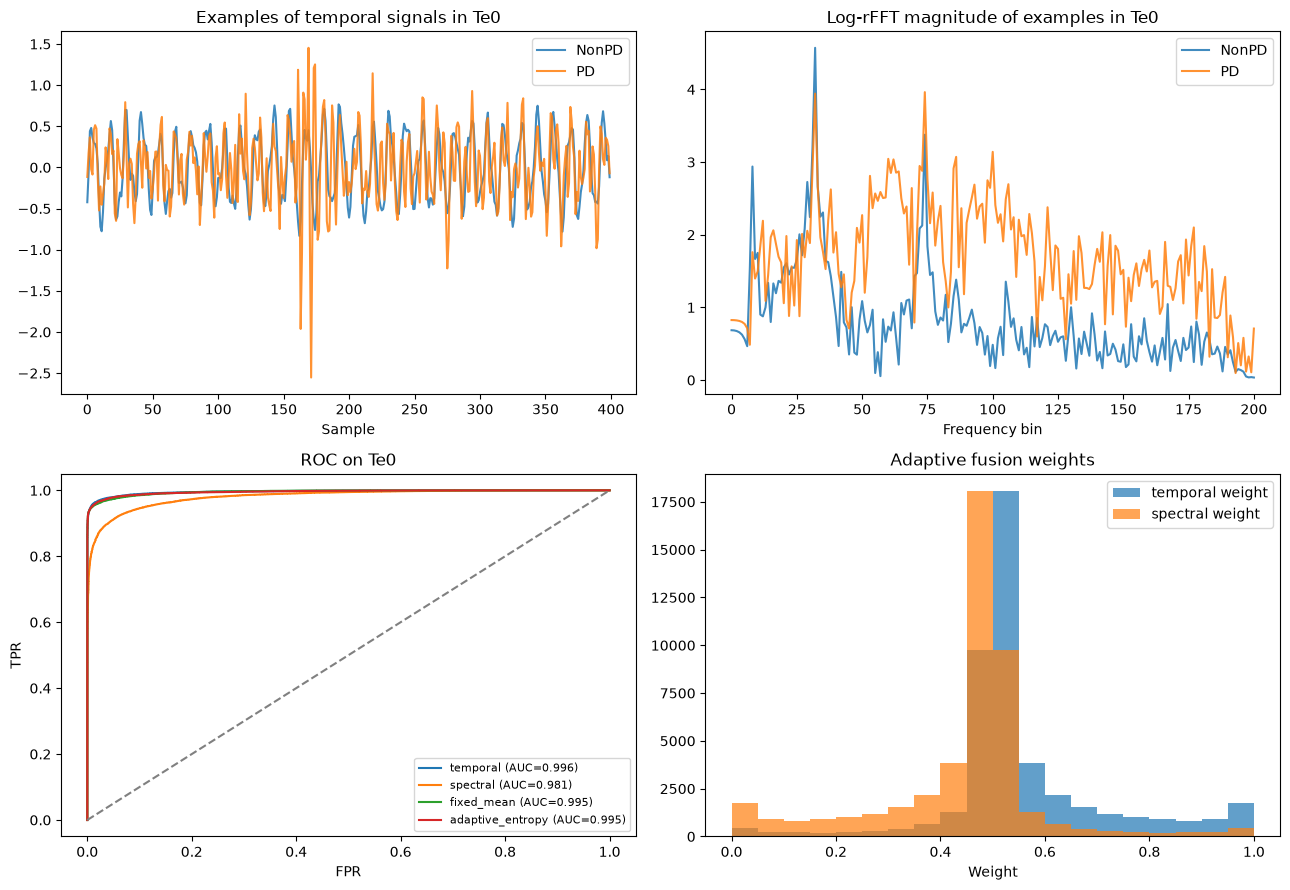

Results saved to: poc/results/summary.json
Evaluation metrics saved to: poc/assessment/metrics.json
Figure saved to: poc/results/poc_summary.png


In [12]:
def normalized_entropy(probability):
    probability = np.clip(probability, 1e-7, 1.0 - 1e-7)
    entropy = -(probability * np.log2(probability) + (1.0 - probability) * np.log2(1.0 - probability))
    return entropy


def adaptive_fusion(temporal_prob, spectral_prob):
    temporal_reliability = 1.0 - normalized_entropy(temporal_prob)
    spectral_reliability = 1.0 - normalized_entropy(spectral_prob)
    weights = np.column_stack([temporal_reliability, spectral_reliability]) + 1e-6
    weights = weights / weights.sum(axis=1, keepdims=True)
    fused = weights[:, 0] * temporal_prob + weights[:, 1] * spectral_prob
    return fused, weights


val_probabilities = {
    'temporal': probabilities['temporal']['val'],
    'spectral': probabilities['spectral']['val'],
    'fixed_mean': 0.5 * (probabilities['temporal']['val'] + probabilities['spectral']['val']),
}
test_probabilities = {
    'temporal': probabilities['temporal']['test'],
    'spectral': probabilities['spectral']['test'],
    'fixed_mean': 0.5 * (probabilities['temporal']['test'] + probabilities['spectral']['test']),
}
val_probabilities['adaptive_entropy'], val_weights = adaptive_fusion(val_probabilities['temporal'], val_probabilities['spectral'])
test_probabilities['adaptive_entropy'], test_weights = adaptive_fusion(test_probabilities['temporal'], test_probabilities['spectral'])


def select_threshold(labels, probabilities):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = np.array([matthews_corrcoef(labels, probabilities >= threshold) for threshold in thresholds])
    best_score = scores.max()
    candidates = thresholds[np.isclose(scores, best_score)]
    return float(candidates[np.argmin(np.abs(candidates - 0.5))])


def expected_calibration_error(labels, probabilities, bins=10):
    edges = np.linspace(0.0, 1.0, bins + 1)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        mask = (probabilities >= lower) & (probabilities < upper if upper < 1 else probabilities <= upper)
        if mask.any():
            error += mask.mean() * abs(probabilities[mask].mean() - labels[mask].mean())
    return float(error)


def evaluate(labels, probabilities, threshold):
    predictions = probabilities >= threshold
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        'threshold': float(threshold),
        'mcc': float(matthews_corrcoef(labels, predictions)),
        'f1': float(f1_score(labels, predictions, zero_division=0)),
        'accuracy': float(accuracy_score(labels, predictions)),
        'precision': float(precision_score(labels, predictions, zero_division=0)),
        'recall_tpr': float(recall_score(labels, predictions, zero_division=0)),
        'specificity': float(tn / (tn + fp)) if (tn + fp) else 0.0,
        'fpr': float(fp / (fp + tn)) if (fp + tn) else 0.0,
        'roc_auc': float(roc_auc_score(labels, probabilities)),
        'pr_auc': float(average_precision_score(labels, probabilities)),
        'brier': float(brier_score_loss(labels, probabilities)),
        'ece_10_bins': expected_calibration_error(labels, probabilities),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }


thresholds = {name: select_threshold(y_val, values) for name, values in val_probabilities.items()}
metrics = {name: evaluate(y_test, test_probabilities[name], thresholds[name]) for name in test_probabilities}
best_baseline_mcc = max(metrics[name]['mcc'] for name in ('temporal', 'spectral', 'fixed_mean'))
adaptive_gain = metrics['adaptive_entropy']['mcc'] - best_baseline_mcc
success = bool(adaptive_gain >= 0.005)
automatic_recommendation = 'GO' if success else 'REVISE'

results_table = pd.DataFrame(metrics).T.sort_values('mcc', ascending=False)
display(results_table[['threshold', 'mcc', 'f1', 'accuracy', 'roc_auc', 'pr_auc', 'recall_tpr', 'fpr', 'ece_10_bins']])
print(f'Best baseline MCC: {best_baseline_mcc:.4f}')
print(f'Adaptive gain versus best baseline: {adaptive_gain:.4f}')
print(f'PoC criterion met: {success}; automatic recommendation: {automatic_recommendation}')


def git_commit():
    try:
        return subprocess.check_output(['git', '-C', str(PROJECT_ROOT), 'rev-parse', 'HEAD'], text=True).strip()
    except Exception:
        return 'unavailable'


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


result_dir = Path(os.environ.get('PD_POC_RESULTS_DIR', str(PROJECT_ROOT / 'poc' / 'results')))
result_dir.mkdir(parents=True, exist_ok=True)
summary = {
    'poc': 'partial-discharge-adaptive-fusion',
    'dataset': {'id': dataset.dataset_id, 'version': dataset.version, 'files': list(PARTITION_FILES)},
    'protocol': {'train': 'Tr0.mat', 'validation': 'Va0.mat', 'test': 'Te0.mat', 'excluded': ['Te1.mat', 'Te2.mat']},
    'counts': {file_id: {str(key): value for key, value in sorted(Counter(labels.tolist()).items())} for file_id, (_, labels) in partitions.items()},
    'configuration': {'seed': SEED, 'device': str(DEVICE), 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'batch_size': BATCH_SIZE, 'torch_threads': torch.get_num_threads()},
    'representations': {'temporal': 'standardized raw signal, 400 samples', 'spectral': 'standardized log magnitude rFFT, 201 bins'},
    'training_history': histories,
    'calibration_temperature': temperatures,
    'thresholds_selected_on_Va0': thresholds,
    'metrics_on_Te0': metrics,
    'criterion': {'minimum_adaptive_gain_mcc': 0.005, 'best_baseline_mcc': best_baseline_mcc, 'adaptive_gain_mcc': adaptive_gain, 'met': success, 'automatic_recommendation': automatic_recommendation},
    'provenance': {'repository_commit': git_commit(), 'python': sys.version, 'numpy': np.__version__, 'pandas': pd.__version__, 'torch': torch.__version__, 'dataset_sha256': {key: file_sha256(value) for key, value in PARTITION_PATHS.items()}},
}

summary_path = result_dir / 'summary.json'
summary_path.write_text(json.dumps(summary, indent=2, sort_keys=True), encoding='utf-8')
assessment_metrics_path = PROJECT_ROOT / 'poc' / 'assessment' / 'metrics.json'
assessment_metrics_path.write_text(json.dumps(summary, indent=2, sort_keys=True), encoding='utf-8')

evidence_lines = [
    '# Evidence',
    '',
    'PoC executed with the leakage-safe Tr0/Va0/Te0 protocol.',
    '',
    f'- Dataset: `{dataset.dataset_id}@{dataset.version}`.',
    f'- Workspace commit: `{summary["provenance"]["repository_commit"]}`.',
    f'- Seed/device: `{SEED}` / `{DEVICE}`.',
    f'- Loaded partitions: `{", ".join(loaded_partitions)}`; Te1.mat and Te2.mat were not loaded.',
    f'- Best baseline MCC on Te0: `{best_baseline_mcc:.4f}`.',
    f'- Adaptive fusion MCC: `{metrics["adaptive_entropy"]["mcc"]:.4f}`.',
    f'- Adaptive gain: `{adaptive_gain:.4f}`; criterion >= 0.005: `{success}`; automatic recommendation: `{automatic_recommendation}`.',
    '',
    'Complete metrics are in `poc/assessment/metrics.json` and `poc/results/summary.json`.',
]
(PROJECT_ROOT / 'poc' / 'assessment' / 'evidence.md').write_text(chr(10).join(evidence_lines) + chr(10), encoding='utf-8')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for label, label_name, color in [(0, 'NonPD', 'tab:blue'), (1, 'PD', 'tab:orange')]:
    index = int(np.flatnonzero(y_test == label)[0])
    axes[0, 0].plot(X_test[index], label=label_name, color=color, alpha=0.85)
    spectrum = fft_magnitude(X_test[index:index + 1])[0]
    axes[0, 1].plot(spectrum, label=label_name, color=color, alpha=0.85)
axes[0, 0].set_title('Examples of temporal signals in Te0')
axes[0, 0].set_xlabel('Sample')
axes[0, 0].legend()
axes[0, 1].set_title('Log-rFFT magnitude of examples in Te0')
axes[0, 1].set_xlabel('Frequency bin')
axes[0, 1].legend()
from sklearn.metrics import roc_curve
for name, values in test_probabilities.items():
    fpr_curve, tpr_curve, _ = roc_curve(y_test, values)
    axes[1, 0].plot(fpr_curve, tpr_curve, label=f'{name} (AUC={metrics[name]["roc_auc"]:.3f})')
axes[1, 0].plot([0, 1], [0, 1], '--', color='grey')
axes[1, 0].set_title('ROC on Te0')
axes[1, 0].set_xlabel('FPR')
axes[1, 0].set_ylabel('TPR')
axes[1, 0].legend(fontsize=8)
axes[1, 1].hist(test_weights[:, 0], bins=20, alpha=0.7, label='temporal weight')
axes[1, 1].hist(test_weights[:, 1], bins=20, alpha=0.7, label='spectral weight')
axes[1, 1].set_title('Adaptive fusion weights')
axes[1, 1].set_xlabel('Weight')
axes[1, 1].legend()
fig.tight_layout()
figure_path = result_dir / 'poc_summary.png'
fig.savefig(figure_path, dpi=140)
display(fig)
plt.close(fig)
print(f'Results saved to: {summary_path.relative_to(PROJECT_ROOT)}')
print(f'Evaluation metrics saved to: {assessment_metrics_path.relative_to(PROJECT_ROOT)}')
print(f'Figure saved to: {figure_path.relative_to(PROJECT_ROOT)}')
assert all(np.isfinite(value) for method in metrics.values() for value in method.values() if isinstance(value, (int, float)))
assert set(loaded_partitions) == {'Tr0.mat', 'Va0.mat', 'Te0.mat'}
